# LeetCode #623: Add One Row to Tree

https://leetcode.com/problems/add-one-row-to-tree/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **DFS (recursive)** | $O(n)$ | $O(h)$ |
| **Optimal: BFS Level Order ★** | $O(n)$ | $O(n)$ |

---

## Understanding the Methods

### DFS (recursive)
Recursively pass the current depth; when depth equals `d-1`, insert new nodes between the current node and its children. Space is $O(h)$ for the stack.

### Optimal: BFS Level Order ★
BFS down to depth `d-1`. At that level, wrap each node's existing children with new nodes of value `val`. Special case: if `d == 1`, create a new root with the old tree as its left child. BFS makes the level boundary explicit and is simpler to reason about.

**Why this is better than DFS:** BFS processes exactly the right level without passing depth state through recursion, and the level boundary is naturally managed by the queue.

**Constraints:**
* The number of nodes in the tree is in the range $[1, 10^4]$
* The depth of the tree is in the range $[1, 10^4]$
* $1 \le d \le$ depth of tree $+ 1$
* $-100 \le \text{val} \le 100$


## Solutions

### C#

In [ ]:
public TreeNode AddOneRow(TreeNode root, int val, int depth) {
    // Special case: new node becomes the root, original tree is its left child
    if (depth == 1) { var nr = new TreeNode(val); nr.left = root; return nr; }
    var queue = new Queue<TreeNode>();
    queue.Enqueue(root);
    // BFS down to depth d-1
    for (int d = 1; d < depth - 1; d++) {
        int sz = queue.Count;
        while (sz-- > 0) {
            var node = queue.Dequeue();
            if (node.left  != null) queue.Enqueue(node.left);
            if (node.right != null) queue.Enqueue(node.right);
        }
    }
    // Insert new nodes between each depth-(d-1) node and its original children
    while (queue.Count > 0) {
        var node = queue.Dequeue();
        var l = new TreeNode(val); l.left  = node.left;  node.left  = l;
        var r = new TreeNode(val); r.right = node.right; node.right = r;
    }
    return root;
}

### Python

In [ ]:
from collections import deque

def add_one_row(root, val: int, depth: int):
    # Special case: new node becomes the root, original tree is its left child
    if depth == 1:
        nr = TreeNode(val)
        nr.left = root
        return nr
    queue = deque([root])
    # BFS down to depth d-1
    for _ in range(depth - 2):
        for _ in range(len(queue)):
            node = queue.popleft()
            if node.left:  queue.append(node.left)
            if node.right: queue.append(node.right)
    # Insert new nodes between each depth-(d-1) node and its original children
    for node in queue:
        l, r = TreeNode(val), TreeNode(val)
        l.left,  node.left  = node.left,  l
        r.right, node.right = node.right, r
    return root

### Go

In [ ]:
func addOneRow(root *TreeNode, val int, depth int) *TreeNode {
    // Special case: new node becomes the root, original tree is its left child
    if depth == 1 { return &TreeNode{Val: val, Left: root} }
    queue := []*TreeNode{root}
    // BFS down to depth d-1
    for d := 1; d < depth-1; d++ {
        next := []*TreeNode{}
        for _, node := range queue {
            if node.Left  != nil { next = append(next, node.Left) }
            if node.Right != nil { next = append(next, node.Right) }
        }
        queue = next
    }
    // Insert new nodes between each depth-(d-1) node and its original children
    for _, node := range queue {
        l := &TreeNode{Val: val, Left: node.Left}
        r := &TreeNode{Val: val, Right: node.Right}
        node.Left, node.Right = l, r
    }
    return root
}

### Rust

In [ ]:
pub fn add_one_row(root: Option<Box<TreeNode>>, val: i32, depth: i32) -> Option<Box<TreeNode>> {
    // Special case: new node becomes the root, original tree is its left child
    if depth == 1 {
        return Some(Box::new(TreeNode { val, left: root, right: None }));
    }
    // Recursive DFS to reach depth d-1, then insert new layer
    fn insert(node: &mut Option<Box<TreeNode>>, val: i32, d: i32) {
        if let Some(n) = node {
            if d == 2 {
                // Insert new nodes between this node and its original children
                let old_left  = n.left.take();
                let old_right = n.right.take();
                n.left  = Some(Box::new(TreeNode { val, left: old_left,  right: None }));
                n.right = Some(Box::new(TreeNode { val, left: None, right: old_right }));
            } else {
                insert(&mut n.left,  val, d - 1);
                insert(&mut n.right, val, d - 1);
            }
        }
    }
    let mut root = root;
    insert(&mut root, val, depth);
    root
}

## Example Scenarios

**1. Common Case**
**Input:** `root = [4,2,6,3,1,5], val = 1, depth = 2`
BFS reaches depth 1 (root=4). Insert new nodes: left child of 4 gets val=1 with original left (2) as its left child; right child of 4 gets val=1 with original right (6) as its right child. Result: [4,1,1,2,null,null,6,3,1,5].

**2. Slightly Complex**
**Input:** `root = [4,2,6,3,1,5], val = 1, depth = 3`
BFS to depth 2: nodes {2,6}. For node 2: new left child (val=1, left=3), new right child (val=1, right=1). For node 6: new left (val=1, left=5), new right (val=1, right=null).

**3. Edge Case: Time Factor**
**Input:** Full binary tree, `depth = h` (leaf level)
BFS traverses all $n - 1$ nodes above the leaf level. At the deepest non-leaf level, every leaf is wrapped with two new val-nodes. $O(n)$ nodes visited.

**4. Edge Case: Space Factor**
**Input:** `depth = 1` (new root)
No BFS needed. A single new root node is created in $O(1)$ time and space — the entire original tree is reattached as its left child unchanged.

**5. Almost-Impossible but Plausible**
**Input:** `root = [1], val = 0, depth = 2`
BFS: depth 1 has only the root. Insert: new left child (val=0, left=null), new right child (val=0, right=null). Original root's children become grandchildren — but there were none. Result: [1,0,0].


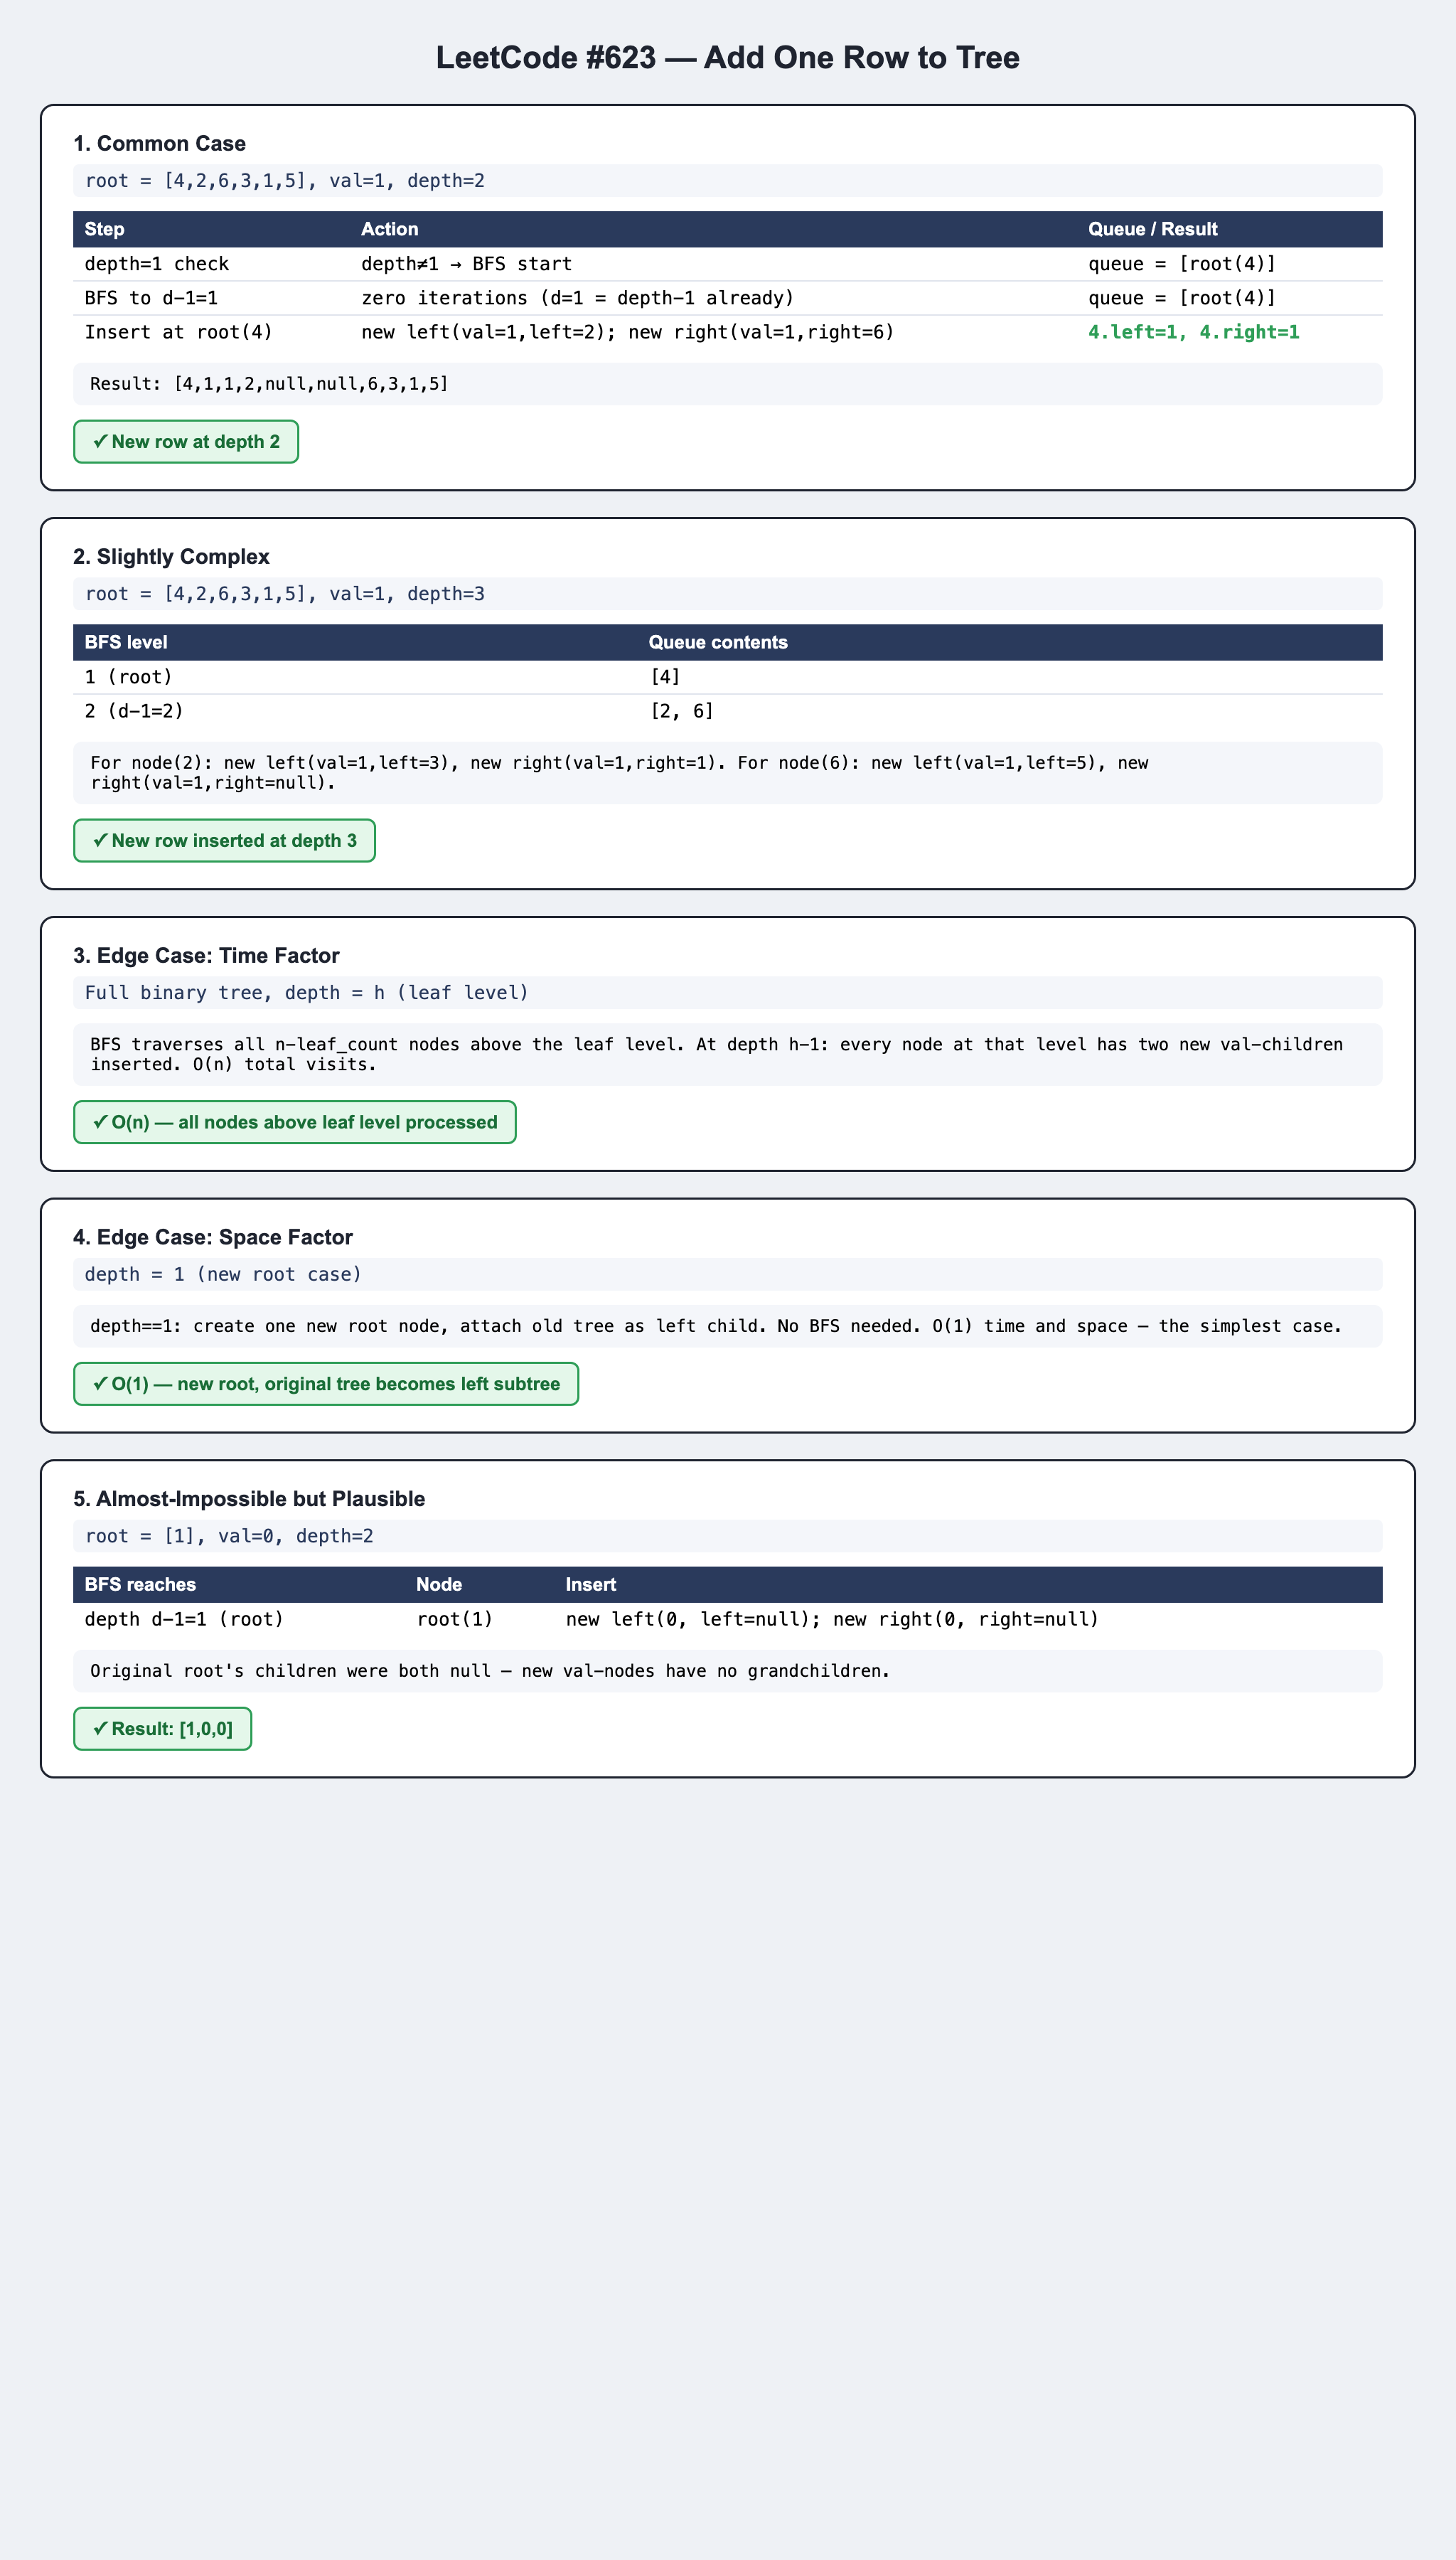